In [1]:
%matplotlib qt
import os
import shutil
import mne
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pickle
import linecache

def save_var(var, fname_pickle):
    with open(fname_pickle, 'wb') as f:
        pickle.dump(var, f, pickle.HIGHEST_PROTOCOL)
    return None

def load_var(fname_pickle):
    with open(fname_pickle, 'rb') as f:
        return pickle.load(f)

def text2matrix(trial_name, subj_name, data_path, n_times=256):
    '''
    Read EEG data from trial files in UCI format and convert to an [n_ch, n_times] matrix.
    '''
    # Get filename
    fname = os.path.join(data_path, subj_name, trial_name)
    
    # Read EEG voltages in a table and reshape into a matrix
    table = np.loadtxt(fname, dtype='str')
    voltages = np.array([float(v) for v in table[..., 3]]) # voltages are given in the 4th column
    eeg_mat = np.reshape(voltages, (n_times, -1)).T
    
    # Get trial condition from file header
    hdr = linecache.getline(fname, 4) # trial condition is given in the 4th line
    cond = hdr[2:6]
    if "err" not in hdr:
        if "S1" in cond:
            event_id = 1
        elif "S2 m" in cond:
            event_id = 2
        elif "S2 n" in cond:
            event_id = 3
        else:
            raise ValueError('Event condition not identified.')
    else:
        if "S2 m" in cond:
            event_id = 4
        elif "S2 n" in cond:
            event_id = 5
        else:
            raise ValueError('Event condition not identified.')
    
    return eeg_mat, event_id

In [3]:
# Given
data_path = '/Users/chholakp2/data/aud'
dir_entries = os.scandir(data_path)
subj_names = sorted([entry.name for entry in dir_entries if entry.is_dir()])

# Create a file with a list of all channel names

In [4]:
# subj_name = subj_names[0]
# trial_names = os.listdir(os.path.join(data_path, subj_name))
# trial_name = trial_names[0]
# print(subj_name)
# print(trial_name)

# fname = os.path.join(data_path, subj_name, trial_name)
# table = np.loadtxt(fname, dtype='str')
# ch_names_col = np.array([v for v in table[..., 1]]) # channel names are given in the 2nd column

# ch_names = [ch_names_col[i*256] for i in range(64)]
# print(len(ch_names))
# print(ch_names)

# fname_ch_names = './HelperFiles/channelNamesUCI.pickle'
# save_var(ch_names, fname_ch_names)

# ch_names = load_var(fname_ch_names)
# print(ch_names)

# Read data into matrices and save as MNE-epochs objects

In [5]:
sfreq = 256 # Hz
new_data_path = '/Users/chholakp2/data/aud-mne/'
ch_names = load_var('./HelperFiles/channelNamesUCI.pickle')
ch_mapping = {
    'FP1': 'Fp1',
    'FP2': 'Fp2',
    'FZ': 'Fz',
    'CZ': 'Cz',
    'PZ': 'Pz',
    'FPZ': 'Fpz',
    'AFZ': 'AFz',
    'FCZ': 'FCz',
    'POZ': 'POz',
    'OZ': 'Oz',
    'CPZ': 'CPz',
}

# Set channel types
ch_types = ['eeg'] * 64
for i_ch, ch_name in enumerate(ch_names):
    if ch_name.lower() in ['x', 'y', 'nd']:
        ch_types[i_ch] = 'misc'

# Create an info object and correct channel names
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
mne.rename_channels(info, ch_mapping)

In [6]:
# Start clocking execution
startTime = time.time()

names_dict = {}
for i_sub, subj_name in enumerate(subj_names):
    trial_names = sorted(os.listdir(os.path.join(data_path, subj_name)))
    epochs_data = []; events = []
    for trial_name in trial_names:
        eeg, event_id = text2matrix(trial_name, subj_name, data_path)
        epochs_data.append(eeg)
        i_trl = int(trial_name[-3:])
        events.append([int(i_trl*256), 0, event_id])
    events = np.array(events)

    # Create MNE-Epochs object for each subject
    epochs = mne.EpochsArray(epochs_data, info=info, events=events)
    
    # Add sensor locations
    epochs.set_montage('standard_1020')
    
    # Bandpass filter
    epochs.filter(l_freq=0.02, h_freq=50)

    # Create new subject name
    if subj_name[3] == "a":
        new_subj_name = "aud-%03d" % (i_sub + 1)
    elif subj_name[3] == "c":
        new_subj_name = "hcv-%03d" % (i_sub + 1)
    else:
        raise ValueError('Invalid subject name.')

    # Keep track of the allotted new subject names
    names_dict[subj_name] = new_subj_name

    # Get new subject folder name
    new_subj_fldr_path = os.path.join(new_data_path, new_subj_name)

    # If subject folder already exists, delete the existing folder
    if os.path.exists(new_subj_fldr_path):
        print('Deleting existing subject folder for', new_subj_name)
        shutil.rmtree(new_subj_fldr_path)

    # Create new subject folder
    print('Creating new subject folder path for', new_subj_name)
    os.mkdir(new_subj_fldr_path)

    # Save epochs file to subject's folder
    fpath_epochs = os.path.join(new_subj_fldr_path, new_subj_name + '-epo.fif')
    print('Saving epochs data for', subj_name, 'in', fpath_epochs)
    epochs.save(fpath_epochs, overwrite=True)

# End clocking execution and display result
executionTime = (time.time() - startTime)
print('Execution time in seconds:', str(executionTime))

# Save the dictionary tracking the names allotted in a file
data = {'UCI': names_dict.keys(), 'MNE': names_dict.values()}
names_df = pd.DataFrame(data)
print(names_df)
names_df.to_csv(os.path.join(new_data_path, 'names-UCI-TO-MNE.csv'), index=False)

Not setting metadata
88 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Setting up band-pass filter from 0.02 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.02
- Lower transition bandwidth: 0.02 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 42241 samples (165.004 sec)



/var/folders/8s/6ch1361n4dz5r08lps2_3d_n34sk04/T/ipykernel_72858/1663014177.py:22: RuntimeWarning: filter_length (42241) is longer than the signal (256), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.02, h_freq=50)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 5368 out of 5368 | elapsed:    8.9s finished


Deleting existing subject folder for aud-001
Creating new subject folder path for aud-001
Saving epochs data for co2a0000364 in /Users/chholakp2/data/aud-mne/aud-001/aud-001-epo.fif
Not setting metadata
93 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Setting up band-pass filter from 0.02 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.02
- Lower transition bandwidth: 0.02 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 42241 samples (165.004 sec)



/var/folders/8s/6ch1361n4dz5r08lps2_3d_n34sk04/T/ipykernel_72858/1663014177.py:22: RuntimeWarning: filter_length (42241) is longer than the signal (256), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.02, h_freq=50)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 5673 out of 5673 | elapsed:    9.6s finished


Deleting existing subject folder for aud-002
Creating new subject folder path for aud-002
Saving epochs data for co2a0000365 in /Users/chholakp2/data/aud-mne/aud-002/aud-002-epo.fif
Not setting metadata
74 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Setting up band-pass filter from 0.02 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.02
- Lower transition bandwidth: 0.02 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 42241 samples (165.004 sec)



...

/var/folders/8s/6ch1361n4dz5r08lps2_3d_n34sk04/T/ipykernel_72858/1663014177.py:22: RuntimeWarning: filter_length (42241) is longer than the signal (256), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.02, h_freq=50)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 4331 out of 4331 | elapsed:    6.6s finished


Deleting existing subject folder for aud-121
Creating new subject folder path for aud-121
Saving epochs data for co3a0000461 in /Users/chholakp2/data/aud-mne/aud-121/aud-121-epo.fif
Not setting metadata
111 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Setting up band-pass filter from 0.02 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.02
- Lower transition bandwidth: 0.02 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 42241 samples (165.004 sec)



/var/folders/8s/6ch1361n4dz5r08lps2_3d_n34sk04/T/ipykernel_72858/1663014177.py:22: RuntimeWarning: filter_length (42241) is longer than the signal (256), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.02, h_freq=50)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s


Deleting existing subject folder for hcv-122
Creating new subject folder path for hcv-122
Saving epochs data for co3c0000402 in /Users/chholakp2/data/aud-mne/hcv-122/hcv-122-epo.fif
Execution time in seconds: 3336.5981957912445
             UCI      MNE
0    co2a0000364  aud-001
1    co2a0000365  aud-002
2    co2a0000368  aud-003
3    co2a0000369  aud-004
4    co2a0000370  aud-005
..           ...      ...
117  co3a0000458  aud-118
118  co3a0000459  aud-119
119  co3a0000460  aud-120
120  co3a0000461  aud-121
121  co3c0000402  hcv-122

[122 rows x 2 columns]


[Parallel(n_jobs=1)]: Done 6771 out of 6771 | elapsed:   12.1s finished


# Read saved MNE-Epochs object

In [7]:
data_path = '/Users/chholakp2/data/aud-mne/'
subj_name = 'aud-001'
fpath_epx = os.path.join(data_path, subj_name, subj_name + '-epo.fif')

epochs = mne.read_epochs(fpath_epx)
epochs.pick_types(eeg=True)
epochs.info

Reading /Users/chholakp2/data/aud-mne/aud-001/aud-001-epo.fif ...
    Found the data of interest:
        t =       0.00 ...     996.09 ms
        0 CTF compensation matrices available
0 bad epochs dropped
Not setting metadata
88 matching events found
No baseline correction applied
0 projection items activated


<Info | 10 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F8, AF1, AF2, Fz, F4, F3, FC6, FC5, FC2, FC1, T8, ...
 chs: 61 EEG
 custom_ref_applied: False
 dig: 64 items (3 Cardinal, 61 EEG)
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 61
 projs: []
 sfreq: 256.0 Hz
>

Using matplotlib as 2D backend.


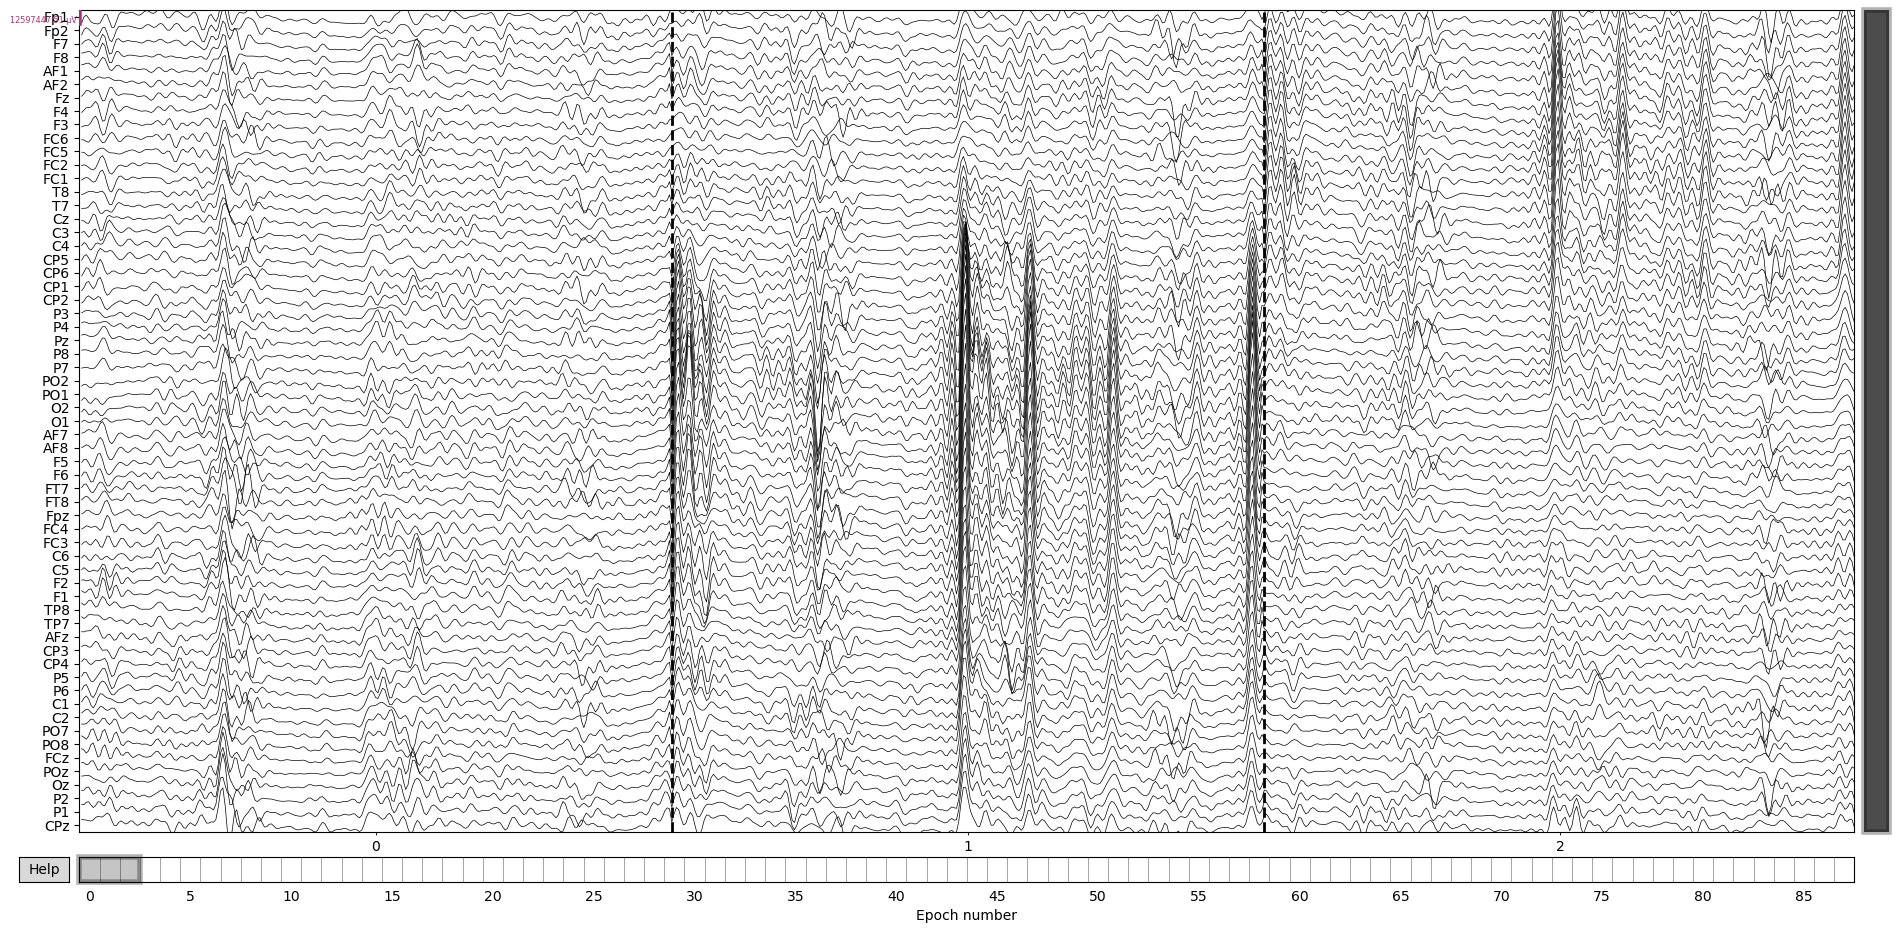

In [8]:
epochs.plot(n_channels=len(epochs.info['ch_names']), n_epochs=3, scalings='auto')

    Using multitaper spectrum estimation with 7 DPSS windows


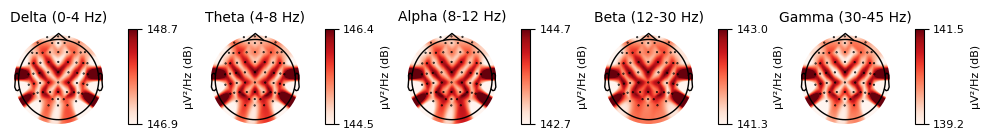

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [9]:
epochs.plot_psd_topomap()